<a href="https://colab.research.google.com/github/Ariharan-10/droneproject/blob/main/drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amineipad/drone-sound-audio-detection")

print("Path to dataset files:", path)

100%|██████████| 276M/276M [00:03<00:00, 83.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amineipad/drone-sound-audio-detection/versions/1


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/drone_detection"

folders = [
    "dataset/drone",
    "dataset/non_drone",
    "models",
    "results"
]

for folder in folders:
    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("Project folders created successfully.")

Project folders created successfully.


In [ ]:
!pip install librosa soundfile

In [ ]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tensorflow.keras import layers
from tensorflow.keras import models

In [ ]:
!git clone https://github.com/DroneDetectionThesis/Drone-detection-dataset.git

Cloning into 'Drone-detection-dataset'...
remote: Enumerating objects: 1572, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 1572 (delta 55), reused 110 (delta 52), pack-reused 1457 (from 1)
Receiving objects: 100% (1572/1572), 291.86 MiB | 14.14 MiB/s, done.
Resolving deltas: 100% (99/99), done.
Updating files: 100% (1396/1396), done.


In [ ]:
!find Drone-detection-dataset -type f | head -30

Drone-detection-dataset/README.md
Drone-detection-dataset/LICENSE
Drone-detection-dataset/.git/logs/refs/remotes/origin/HEAD
Drone-detection-dataset/.git/logs/refs/heads/master
Drone-detection-dataset/.git/logs/HEAD
Drone-detection-dataset/.git/refs/remotes/origin/HEAD
Drone-detection-dataset/.git/refs/heads/master
Drone-detection-dataset/.git/info/exclude
Drone-detection-dataset/.git/objects/pack/pack-4f4a07992d2265a1fe2cdb5659f90d99c2260981.idx
Drone-detection-dataset/.git/objects/pack/pack-4f4a07992d2265a1fe2cdb5659f90d99c2260981.pack
Drone-detection-dataset/.git/packed-refs
Drone-detection-dataset/.git/config
Drone-detection-dataset/.git/index
Drone-detection-dataset/.git/description
Drone-detection-dataset/.git/hooks/pre-merge-commit.sample
Drone-detection-dataset/.git/hooks/fsmonitor-watchman.sample
Drone-detection-dataset/.git/hooks/commit-msg.sample
Drone-detection-dataset/.git/hooks/pre-rebase.sample
Drone-detection-dataset/.git/hooks/pre-receive.sample
Drone-detection-dataset

In [ ]:
import os

DATASET_PATH = "/content/Drone-detection-dataset"

for root, dirs, files in os.walk(DATASET_PATH):

    print("\nFolder:", root)

    for file in files[:10]:
        print("  ", file)


Folder: /content/Drone-detection-dataset
   README.md
   LICENSE
   Demo_IR_DRONE_146.mp4
   Demo_V_DRONE_017.mp4

Folder: /content/Drone-detection-dataset/.git
   packed-refs
   config
   index
   description
   HEAD

Folder: /content/Drone-detection-dataset/.git/logs
   HEAD

Folder: /content/Drone-detection-dataset/.git/logs/refs

Folder: /content/Drone-detection-dataset/.git/logs/refs/remotes

Folder: /content/Drone-detection-dataset/.git/logs/refs/remotes/origin
   HEAD

Folder: /content/Drone-detection-dataset/.git/logs/refs/heads
   master

Folder: /content/Drone-detection-dataset/.git/refs

Folder: /content/Drone-detection-dataset/.git/refs/remotes

Folder: /content/Drone-detection-dataset/.git/refs/remotes/origin
   HEAD

Folder: /content/Drone-detection-dataset/.git/refs/heads
   master

Folder: /content/Drone-detection-dataset/.git/refs/tags

Folder: /content/Drone-detection-dataset/.git/info
   exclude

Folder: /content/Drone-detection-dataset/.git/objects

Folder: /conten

In [ ]:
audio_extensions = (
    ".wav",
    ".mp3",
    ".flac",
    ".ogg"
)

audio_files = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(audio_extensions):

            audio_files.append(
                os.path.join(root, file)
            )

print(
    "Total audio files:",
    len(audio_files)
)

Total audio files: 90


In [ ]:
import os
import shutil

SOURCE_AUDIO = "/content/Drone-detection-dataset/Data/Audio"

DRONE_DIR = f"{PROJECT_DIR}/dataset/drone"
NON_DRONE_DIR = f"{PROJECT_DIR}/dataset/non_drone"

os.makedirs(DRONE_DIR, exist_ok=True)
os.makedirs(NON_DRONE_DIR, exist_ok=True)

for file in os.listdir(SOURCE_AUDIO):

    if not file.lower().endswith(".wav"):
        continue

    source = os.path.join(SOURCE_AUDIO, file)

    if file.upper().startswith("DRONE_"):
        destination = os.path.join(DRONE_DIR, file)

    elif (
        file.upper().startswith("BACKGROUND_")
        or file.upper().startswith("HELICOPTER_")
    ):
        destination = os.path.join(NON_DRONE_DIR, file)

    else:
        continue

    shutil.copy2(source, destination)

print("Audio files organized successfully.")

In [ ]:
copy_audio_files(
    source_drone,
    destination_drone
)

copy_audio_files(
    source_background,
    destination_non_drone
)

copy_audio_files(
    source_helicopter,
    destination_non_drone
)

NameError: name 'copy_audio_files' is not defined

In [ ]:
drone_files = [
    f for f in os.listdir(DRONE_DIR)
    if f.lower().endswith(".wav")
]

non_drone_files = [
    f for f in os.listdir(NON_DRONE_DIR)
    if f.lower().endswith(".wav")
]

print("Drone files:", len(drone_files))
print("Non-drone files:", len(non_drone_files))

Drone files: 30
Non-drone files: 60


In [ ]:
import glob
import os
import shutil

audio_files = glob.glob(
    "/content/Drone-detection-dataset/**/*.wav",
    recursive=True
)

print("Total WAV files:", len(audio_files))

for f in audio_files:
    print(f)

Total WAV files: 90
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_029.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_022.wav
/content/Drone-detection-dataset/Data/Audio/BACKGROUND_003.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_014.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_001.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_013.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_014.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_027.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_005.wav
/content/Drone-detection-dataset/Data/Audio/BACKGROUND_005.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_017.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_009.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_021.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_004.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_026.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_023.wav
/c

In [ ]:
SAMPLE_RATE = 16000
DURATION = 3
N_MELS = 128
IMG_SIZE = 128

def audio_to_mel(file):

    audio, sr = librosa.load(
        file,
        sr=SAMPLE_RATE,
        duration=DURATION
    )

    target_length = SAMPLE_RATE * DURATION

    if len(audio) < target_length:

        audio = np.pad(
            audio,
            (0, target_length - len(audio))
        )

    else:

        audio = audio[:target_length]

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=N_MELS
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    mel_db = tf.image.resize(
        mel_db[..., np.newaxis],
        [IMG_SIZE, IMG_SIZE]
    )

    return mel_db.numpy()

In [ ]:
import os
import glob

DATASET_PATH = "/content/Drone-detection-dataset"

# Find every audio file recursively
audio_files = []

for ext in ["*.wav", "*.mp3", "*.flac", "*.ogg"]:
    audio_files.extend(
        glob.glob(
            os.path.join(DATASET_PATH, "**", ext),
            recursive=True
        )
    )

print("Total audio files:", len(audio_files))

for file in audio_files:
    print(file)

Total audio files: 90
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_029.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_022.wav
/content/Drone-detection-dataset/Data/Audio/BACKGROUND_003.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_014.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_001.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_013.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_014.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_027.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_005.wav
/content/Drone-detection-dataset/Data/Audio/BACKGROUND_005.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_017.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_009.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_021.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_004.wav
/content/Drone-detection-dataset/Data/Audio/DRONE_026.wav
/content/Drone-detection-dataset/Data/Audio/HELICOPTER_023.wav


In [ ]:
for root, dirs, files in os.walk(DATASET_PATH):
    print("\nFOLDER:", root)
    print("SUBFOLDERS:", dirs)
    print("FILES:", files[:10])


FOLDER: /content/Drone-detection-dataset
SUBFOLDERS: ['.git', 'Data']
FILES: ['README.md', 'LICENSE', 'Demo_IR_DRONE_146.mp4', 'Demo_V_DRONE_017.mp4']

FOLDER: /content/Drone-detection-dataset/.git
SUBFOLDERS: ['logs', 'refs', 'info', 'objects', 'branches', 'hooks']
FILES: ['packed-refs', 'config', 'index', 'description', 'HEAD']

FOLDER: /content/Drone-detection-dataset/.git/logs
SUBFOLDERS: ['refs']
FILES: ['HEAD']

FOLDER: /content/Drone-detection-dataset/.git/logs/refs
SUBFOLDERS: ['remotes', 'heads']
FILES: []

FOLDER: /content/Drone-detection-dataset/.git/logs/refs/remotes
SUBFOLDERS: ['origin']
FILES: []

FOLDER: /content/Drone-detection-dataset/.git/logs/refs/remotes/origin
SUBFOLDERS: []
FILES: ['HEAD']

FOLDER: /content/Drone-detection-dataset/.git/logs/refs/heads
SUBFOLDERS: []
FILES: ['master']

FOLDER: /content/Drone-detection-dataset/.git/refs
SUBFOLDERS: ['remotes', 'heads', 'tags']
FILES: []

FOLDER: /content/Drone-detection-dataset/.git/refs/remotes
SUBFOLDERS: ['orig

In [ ]:
sample_file = os.path.join(
    PROJECT_DIR,
    "dataset/drone",
    drone_files[0]
)
sample_file = os.path.join(
    DRONE_DIR,
    drone_files[0]
)

print("Selected file:")
print(sample_file)

Selected file:
/content/drive/MyDrive/drone_detection/dataset/drone/DRONE_025.wav


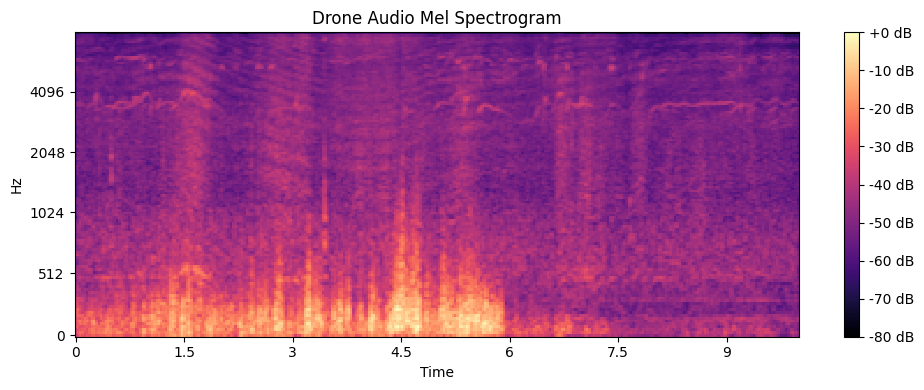

In [ ]:
audio, sr = librosa.load(
    sample_file,
    sr=16000
)

mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    "Drone Audio Mel Spectrogram"
)

plt.tight_layout()

plt.show()

drone

In [ ]:
drone_sample = os.path.join(
    DRONE_DIR,
    drone_files[0]
)

print("Drone sample:", drone_sample)

Drone sample: /content/drive/MyDrive/drone_detection/dataset/drone/DRONE_025.wav


non-drone

In [ ]:
non_drone_sample = os.path.join(
    NON_DRONE_DIR,
    non_drone_files[0]
)

print("Non-drone sample:", non_drone_sample)

Non-drone sample: /content/drive/MyDrive/drone_detection/dataset/non_drone/HELICOPTER_008.wav


In [ ]:
X = []
y = []

classes = {
    "non_drone": 0,
    "drone": 1
}

for class_name, label in classes.items():

    folder = os.path.join(
        PROJECT_DIR,
        "dataset",
        class_name
    )

    for file in os.listdir(folder):

        if not file.lower().endswith(
            audio_extensions
        ):
            continue

        path = os.path.join(
            folder,
            file
        )

        try:

            mel = audio_to_mel(path)

            X.append(mel)
            y.append(label)

        except Exception as e:

            print(
                "Error:",
                file,
                e
            )

X = np.array(X)
y = np.array(y)

print("X:", X.shape)
print("y:", y.shape)

X: (90, 128, 128, 1)
y: (90,)


**split dataset**


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (63, 128, 128, 1)
Validation: (13, 128, 128, 1)
Testing: (14, 128, 128, 1)


**Build CNN**

In [ ]:
model = models.Sequential([

    layers.Input(
        shape=(128, 128, 1)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.4),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
#train
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,
    batch_size=8
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 507ms/step - accuracy: 0.5079 - loss: 9.4982 - val_accuracy: 0.6923 - val_loss: 0.6224
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step - accuracy: 0.6667 - loss: 0.6004 - val_accuracy: 0.6923 - val_loss: 0.5654
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 240ms/step - accuracy: 0.6825 - loss: 0.6327 - val_accuracy: 0.6923 - val_loss: 0.5344
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.6349 - loss: 0.6530 - val_accuracy: 0.6923 - val_loss: 0.5295
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 344ms/step - accuracy: 0.7302 - loss: 0.6122 - val_accuracy: 0.8462 - val_loss: 0.5906
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - accuracy: 0.6984 - loss: 0.5598 - val_accuracy: 0.6154 - val_loss: 0.5769
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 0.6825 - loss: 0.5677 - val_accuracy: 0.6923 - val_loss: 0.5957
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 335ms/step - accuracy: 0.7302 - loss: 0.5482 - val_accuracy: 0.8462 - val_loss:

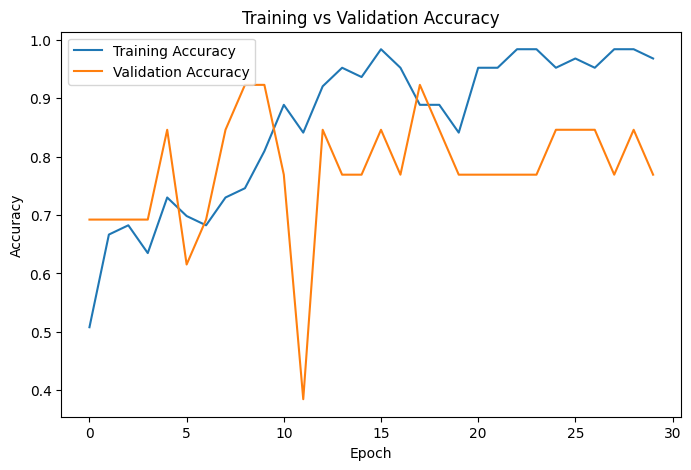

<Figure size 640x480 with 0 Axes>

In [ ]:
#plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.title(
    "Training vs Validation Accuracy"
)

plt.show()
plt.savefig(
    f"{PROJECT_DIR}/results/accuracy.png"
)

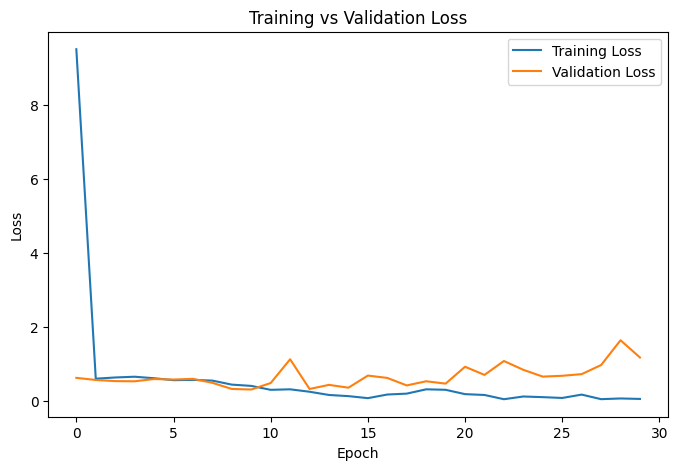

In [ ]:
#loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.title(
    "Training vs Validation Loss"
)

plt.show()

In [ ]:
#evaluate
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print(
    f"Test Accuracy: {accuracy * 100:.2f}%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8571 - loss: 0.7379
Test Accuracy: 85.71%


In [ ]:
#classification report
probabilities = model.predict(
    X_test
)

predictions = (
    probabilities >= 0.5
).astype(int)

print(
    classification_report(
        y_test,
        predictions,
        target_names=[
            "Non-Drone",
            "Drone"
        ]
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
              precision    recall  f1-score   support

   Non-Drone       0.89      0.89      0.89         9
       Drone       0.80      0.80      0.80         5

    accuracy                           0.86        14
   macro avg       0.84      0.84      0.84        14
weighted avg       0.86      0.86      0.86        14



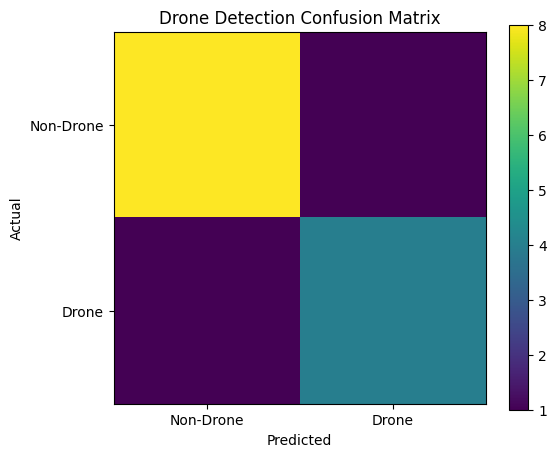

In [ ]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Drone Detection Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Non-Drone", "Drone"]
)

plt.yticks(
    [0, 1],
    ["Non-Drone", "Drone"]
)

plt.colorbar()

plt.show()

In [ ]:
#testing on new audio file
def predict_audio(file):

    mel = audio_to_mel(file)

    mel = np.expand_dims(
        mel,
        axis=0
    )

    probability = model.predict(
        mel,
        verbose=0
    )[0][0]

    if probability >= 0.5:

        result = "DRONE DETECTED"
        confidence = probability

    else:

        result = "NON-DRONE"
        confidence = 1 - probability

    return result, confidence

In [ ]:
test_file = sample_file

result, confidence = predict_audio(
    test_file
)

print("Result:", result)

print(
    f"Confidence: {confidence * 100:.2f}%"
)

Result: DRONE DETECTED
Confidence: 100.00%


In [ ]:
MODEL_PATH = (
    f"{PROJECT_DIR}/models/"
    "drone_audio_model.keras"
)

model.save(MODEL_PATH)

print(
    "Model saved at:",
    MODEL_PATH
)

Model saved at: /content/drive/MyDrive/drone_detection/models/drone_audio_model.keras


**REALTIME TESTING**

In [ ]:
#load the model
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/drone_detection/models/drone_audio_model.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
#install microphone
!pip install -q sounddevice

In [ ]:
from IPython.display import Javascript, display
from google.colab import output
import base64

def record_audio(duration=3):

    js = Javascript("""
    async function recordAudio(duration) {

        const stream =
            await navigator.mediaDevices.getUserMedia({
                audio: true
            });

        const recorder =
            new MediaRecorder(stream);

        let chunks = [];

        recorder.ondataavailable =
            event => chunks.push(event.data);

        recorder.start();

        await new Promise(
            resolve => setTimeout(resolve, duration * 1000)
        );

        recorder.stop();

        await new Promise(
            resolve => recorder.onstop = resolve
        );

        stream.getTracks().forEach(
            track => track.stop()
        );

        const blob = new Blob(
            chunks,
            {type: "audio/webm"}
        );

        const reader = new FileReader();

        return new Promise(resolve => {

            reader.onloadend = () =>
                resolve(reader.result);

            reader.readAsDataURL(blob);
        });
    }

    recordAudio
    """)

    display(js)

    data = output.eval_js(
        f"recordAudio({duration})"
    )

    audio_bytes = base64.b64decode(
        data.split(",")[1]
    )

    filename = "/content/realtime_audio.webm"

    with open(filename, "wb") as f:
        f.write(audio_bytes)

    return filename

In [ ]:
audio_file = record_audio(3)

print("Recorded:", audio_file)

<IPython.core.display.Javascript object>

MessageError: NotFoundError: Requested device not found

In [ ]:
#existing preprocessing
mel = audio_to_mel(
    "realtime_test.wav"
)

mel = np.expand_dims(
    mel,
    axis=0
)

print(mel.shape)

In [ ]:
#prediction
prediction = model.predict(
    mel,
    verbose=0
)

drone_probability = float(
    prediction[0][0]
)

if drone_probability >= 0.5:

    result = "DRONE DETECTED"
    confidence = drone_probability

else:

    result = "NON-DRONE"
    confidence = 1 - drone_probability

print("Result:", result)

print(
    f"Confidence: {confidence * 100:.2f}%"
)

In [ ]:
#repeated microphone check
import time

for i in range(10):

    print("\nRecording...")

    audio_file = record_audio(
        "current_audio.wav",
        duration=3
    )

    mel = audio_to_mel(
        audio_file
    )

    mel = np.expand_dims(
        mel,
        axis=0
    )

    prediction = model.predict(
        mel,
        verbose=0
    )

    probability = float(
        prediction[0][0]
    )

    if probability >= 0.5:

        result = "DRONE DETECTED"
        confidence = probability

    else:

        result = "NON-DRONE"
        confidence = 1 - probability

    print(
        f"{result} | "
        f"Confidence: {confidence * 100:.2f}%"
    )

    time.sleep(0.5)